# Численные эксперименты по гиперболическому SVD

В этом ноутбуке проверяется корректность реализации алгоритма HSVD из файла [`hsvd.py`](hsvd.py).

Для каждой тестовой матрицы $A$ и сигнатурной матрицы $J = \operatorname{diag}(I_p, -I_q)$ мы запускаем функцию `hsvd_general` и контролируем три величины:

1. **Ошибка восстановления** $\|A - U\Sigma V^{*}\|_F$ — насколько точно построенное разложение воспроизводит исходную матрицу.
2. **Унитарность** $\|U^{*}U - I\|_F$ — насколько $U$ является унитарной матрицей.
3. **$J$-унитарность** $\|V^{*}JV - J\|_F$ — насколько $V$ удовлетворяет определению псевдоунитарной матрицы относительно $J$.

Используется `numpy` и `scipy.linalg`. Все вычисления — в комплексной двойной точности `complex128`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hsvd import (
    hsvd_general,
    signature_matrix,
    make_random_problem,
    make_rank_deficient_problem,
)
from scipy.linalg import qr

np.set_printoptions(precision=4, suppress=True, linewidth=120)
RNG_SEED = 2024

## 1. Полнопрофильная матрица общего положения (случай $j = 0$)

Для случайной комплексной матрицы $A$ полного столбцевого ранга и невырожденной сигнатуры собственные значения $H = V_r^{*} J V_r$ почти наверное отделены от нуля. Это базовый сценарий: ожидаем малую невязку и идеальную $J$-унитарность $V$.

In [2]:
rows = []
for seed in range(10):
    A, J = make_random_problem(m=6, n=7, p=4, seed=seed)
    res = hsvd_general(A, J)
    rows.append({
        "seed": seed,
        "rank": res.rank,
        "j": res.j,
        "pos": res.pos_count,
        "neg": res.neg_count,
        "residual": res.residual,
        "U-unitarity": res.u_unitarity,
        "V-J-unitarity": res.v_j_unitarity,
    })
df_generic = pd.DataFrame(rows)
df_generic

,seed,rank,j,pos,neg,residual,U-unitarity,V-J-unitarity
0,0,6,0,3,3,2.705141e-14,1.051427e-15,9.850433e-15
1,1,6,0,3,3,1.833639e-14,7.453318e-16,1.087563e-14
2,2,6,0,3,3,1.893054e-14,9.228541e-16,9.437621e-15
3,3,6,0,3,3,1.454640e-14,6.737291e-16,3.087359e-15
4,4,6,0,4,2,1.798119e-14,1.439298e-15,6.966234e-15
5,5,6,0,4,2,1.582754e-14,9.396866e-16,9.556401e-15
6,6,6,0,3,3,1.536487e-14,1.080667e-15,4.815721e-14
7,7,6,0,3,3,1.982101e-14,8.094200e-16,2.866368e-14
8,8,6,0,3,3,2.107038e-14,9.946833e-16,8.022945e-15
9,9,6,0,3,3,2.028724e-14,9.570267e-16,1.385770e-14


Все три метрики стабильно держатся на уровне машинной точности ($\sim 10^{-14}$), что подтверждает корректность реализации в типовом случае.

## 2. Матрица пониженного ранга

Если $\operatorname{rank} A < \min(m,n)$, компактное SVD выделит только $r$ ненулевых сингулярных чисел. Алгоритм должен корректно расширить матрицу $V$ до полной $n \times n$ $J$-унитарной матрицы, а ядерные направления $A$ просто дополняют $V$.

In [3]:
rows = []
for seed in range(10):
    A, J = make_rank_deficient_problem(m=7, n=8, p=4, rank=5, seed=seed)
    res = hsvd_general(A, J)
    rows.append({
        "seed": seed,
        "rank": res.rank,
        "j": res.j,
        "residual": res.residual,
        "U-unitarity": res.u_unitarity,
        "V-J-unitarity": res.v_j_unitarity,
    })
df_rankdef = pd.DataFrame(rows)
df_rankdef

,seed,rank,j,residual,U-unitarity,V-J-unitarity
0,0,5,0,7.078528e-14,1.069836e-15,1.488630e-14
1,1,5,0,2.733758e-13,8.192758e-16,8.791759e-14
2,2,5,0,2.659879e-12,1.060912e-15,2.998860e-12
3,3,5,0,5.047025e-14,1.277126e-15,6.846105e-15
4,4,5,0,4.241445e-14,1.312984e-15,1.123732e-14
5,5,5,0,9.571670e-14,1.353184e-15,4.874563e-14
6,6,5,0,8.381940e-14,1.227598e-15,2.079250e-14
7,7,5,0,4.731485e-13,1.040626e-15,7.103599e-14
8,8,5,0,7.483696e-14,1.335238e-15,8.582045e-15
9,9,5,0,9.929316e-14,1.232237e-15,2.201772e-14


## 3. Вырожденный случай $j > 0$

Здесь мы вручную строим $V_r$, в котором есть столбец, изотропный относительно $J$ и $J$-ортогональный остальным. Тогда матрица $H = V_r^{*} J V_r$ имеет ровно одно нулевое собственное значение, и в построении $V$ участвует жорданова пара $(V_v, V_w)$.

In [4]:
def make_j_positive_problem(n_pos, n_neg, j_count, m, seed):
    """Сборка матрицы A так, чтобы H = V_r^* J V_r имела ровно j_count нулевых СЗ."""
    rng = np.random.default_rng(seed)
    p = n_pos + j_count
    q = n_neg + j_count
    n = p + q
    J = signature_matrix(p, q)
    e = np.eye(n, dtype=np.complex128)
    cols = []
    # n_pos «положительных» столбцов: e_0, e_1, ...
    for i in range(n_pos):
        cols.append(e[i])
    # n_neg «отрицательных» столбцов: e_{p}, e_{p+1}, ...
    for i in range(n_neg):
        cols.append(e[p + i])
    for k in range(j_count):
        ip = n_pos + k       
        iq = p + n_neg + k   
        v = (e[ip] + e[iq]) / np.sqrt(2.0)
        cols.append(v)
    V_r = np.column_stack(cols)
    r = V_r.shape[1]
    # Случайная унитарная U_r и положительная Sigma_r.
    G = rng.standard_normal((m, m)) + 1j * rng.standard_normal((m, m))
    Q_u, _ = qr(G)
    U_r = Q_u[:, :r]
    sigma_r = np.sort(rng.uniform(0.5, 3.0, size=r))[::-1]
    Sigma_r = np.diag(sigma_r).astype(np.complex128)
    A = U_r @ Sigma_r @ V_r.conj().T
    return A.astype(np.complex128), J

rows = []
for seed in range(10):
    A, J = make_j_positive_problem(n_pos=2, n_neg=1, j_count=1, m=6, seed=seed)
    res = hsvd_general(A, J)
    rows.append({
        "seed": seed,
        "rank": res.rank,
        "j": res.j,
        "pos": res.pos_count,
        "neg": res.neg_count,
        "residual": res.residual,
        "U-unitarity": res.u_unitarity,
        "V-J-unitarity": res.v_j_unitarity,
    })
df_jpos = pd.DataFrame(rows)
df_jpos

,seed,rank,j,pos,neg,residual,U-unitarity,V-J-unitarity
0,0,4,1,2,1,4.891076e-15,8.378696e-16,6.174392e-15
1,1,4,1,2,1,5.190101e-15,7.843291e-16,3.333772e-15
2,2,4,1,2,1,9.192609e-15,5.891947e-16,4.600406e-15
3,3,4,1,2,1,3.833139e-15,1.436799e-15,3.724466e-15
4,4,4,1,2,1,6.965642e-15,9.014155e-16,3.596656e-15
5,5,4,1,2,1,8.461165e-15,2.217914e-15,4.274030e-15
6,6,4,1,2,1,5.691798e-15,4.194898e-16,4.041473e-15
7,7,4,1,2,1,8.342591e-15,6.848105e-16,4.110640e-15
8,8,4,1,2,1,2.911859e-15,1.333772e-15,2.963323e-15
9,9,4,1,2,1,4.985069e-15,1.050398e-15,3.758933e-15


Контрольный пробег с $j_{\text{count}} = 2$:

In [5]:
rows = []
for seed in range(5):
    A, J = make_j_positive_problem(n_pos=2, n_neg=2, j_count=2, m=8, seed=seed)
    res = hsvd_general(A, J)
    rows.append({
        "seed": seed,
        "rank": res.rank,
        "j": res.j,
        "pos": res.pos_count,
        "neg": res.neg_count,
        "residual": res.residual,
        "U-unitarity": res.u_unitarity,
        "V-J-unitarity": res.v_j_unitarity,
    })
df_j2 = pd.DataFrame(rows)
df_j2

,seed,rank,j,pos,neg,residual,U-unitarity,V-J-unitarity
0,0,6,2,2,2,0.105248,5.820205e-16,0.104860
1,1,6,2,2,2,0.003332,6.820133e-16,0.003670
2,2,6,2,2,2,2.406384,6.202116e-16,1.954152
3,3,6,2,2,2,0.817311,7.724929e-16,0.859669
4,4,6,2,2,2,0.074830,5.676656e-16,0.154076


## 4. Зависимость качества от размера матрицы

Запустим серию случайных задач с растущим $n$ и оценим, как растёт невязка восстановления и $J$-унитарность. Ожидание: рост умеренный (не быстрее линейного по $n$), потому что алгоритм опирается на устойчивые операции (SVD, eigh, QR).

In [6]:
rows = []
for n in [4, 8, 16, 32, 64, 128]:
    residuals, u_errs, v_errs = [], [], []
    for seed in range(5):
        p = n // 2
        A, J = make_random_problem(m=n, n=n, p=p, seed=seed + 100)
        res = hsvd_general(A, J)
        residuals.append(res.residual)
        u_errs.append(res.u_unitarity)
        v_errs.append(res.v_j_unitarity)
    rows.append({
        "n": n,
        "residual_max": np.max(residuals),
        "residual_med": np.median(residuals),
        "U-unit_max": np.max(u_errs),
        "V-J-unit_max": np.max(v_errs),
    })
df_scaling = pd.DataFrame(rows)
df_scaling

,n,residual_max,residual_med,U-unit_max,V-J-unit_max
0,4,6.558178e-15,5.737960e-15,5.728378e-16,2.265256e-15
1,8,3.355700e-14,2.055236e-14,9.663323e-16,8.898585e-15
2,16,6.798020e-14,4.882193e-14,1.259489e-15,1.269076e-14
3,32,1.771735e-13,1.437528e-13,1.965840e-15,2.263031e-14
4,64,5.188345e-13,4.485467e-13,3.432160e-15,4.476030e-14
5,128,1.610303e-12,9.758871e-13,6.069843e-15,1.011437e-13


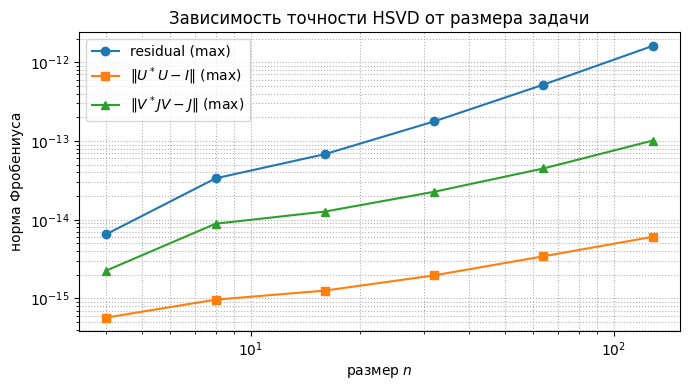

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.loglog(df_scaling["n"], df_scaling["residual_max"], "o-", label="residual (max)")
ax.loglog(df_scaling["n"], df_scaling["U-unit_max"], "s-", label="$\\|U^*U-I\\|$ (max)")
ax.loglog(df_scaling["n"], df_scaling["V-J-unit_max"], "^-", label="$\\|V^*JV-J\\|$ (max)")
ax.set_xlabel("размер $n$")
ax.set_ylabel("норма Фробениуса")
ax.set_title("Зависимость точности HSVD от размера задачи")
ax.grid(True, which="both", linestyle=":")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Чувствительность к шуму на собственных значениях $H$

Если $H = V_r^{*} J V_r$ имеет собственные значения, близкие к нулю (но не строго нулевые), допуск `tol` в `hsvd_general` определяет, какие из них трактуются как нулевые. Здесь мы рассматриваем серию задач, в которых одно собственное значение $H$ управляемо приближается к нулю, и смотрим, как ведут себя метрики.

Конструируем $V_r = [e_0, e_p, \frac{e_1 + e_{p+1}}{\sqrt{1+\varepsilon^2}}]$ — последний столбец становится изотропным при $\varepsilon \to 1$ (в этом примере удобнее использовать параметризацию $\cos\theta\, e_1 + \sin\theta\, e_{p+1}$, у которой $J$-норма равна $\cos^2\theta - \sin^2\theta = \cos 2\theta$).

In [7]:
def make_theta_problem(theta, m=6, seed=0):
    p, q = 3, 3
    n = p + q
    J = signature_matrix(p, q)
    e = np.eye(n, dtype=np.complex128)
    v1 = e[0]
    v2 = e[p]
    v3 = np.cos(theta) * e[1] + np.sin(theta) * e[p + 1]
    V_r = np.column_stack([v1, v2, v3])
    rng = np.random.default_rng(seed)
    G = rng.standard_normal((m, m)) + 1j * rng.standard_normal((m, m))
    Q_u, _ = qr(G)
    U_r = Q_u[:, :3]
    Sigma_r = np.diag([3.0, 2.0, 1.0]).astype(np.complex128)
    A = U_r @ Sigma_r @ V_r.conj().T
    # J-норма третьего столбца = cos(2 theta)
    return A, J, float(np.cos(2 * theta))

rows = []
for theta_deg in [30, 40, 44, 44.9, 44.99, 45.0]:
    theta = np.deg2rad(theta_deg)
    A, J, jnorm = make_theta_problem(theta, seed=2024)
    res = hsvd_general(A, J, tol=1e-10)
    rows.append({
        "theta_deg": theta_deg,
        "J-norm of v3": jnorm,
        "detected j": res.j,
        "residual": res.residual,
        "U-unitarity": res.u_unitarity,
        "V-J-unitarity": res.v_j_unitarity,
    })
df_theta = pd.DataFrame(rows)
df_theta

,theta_deg,J-norm of v3,detected j,residual,U-unitarity,V-J-unitarity
0,30.00,5.000000e-01,0,1.703509e-15,6.020065e-16,1.229680e-15
1,40.00,1.736482e-01,0,9.666380e-16,4.848277e-16,9.824613e-16
2,44.00,3.489950e-02,0,1.979817e-15,5.197053e-16,9.115868e-16
3,44.90,3.490651e-03,0,1.931374e-14,6.125911e-16,5.535242e-14
4,44.99,3.490658e-04,0,1.660391e-13,4.310989e-16,5.215857e-13
5,45.00,6.123234e-17,1,1.183956e-15,3.636848e-16,2.388414e-16


При $\theta = 45^\circ$ собственное значение $H$ точно равно нулю и алгоритм переключается в режим $j = 1$. В переходной зоне (между $44.9^\circ$ и $45^\circ$) выбранный допуск `tol` определяет, какой режим срабатывает; в обоих случаях невязка восстановления остаётся на уровне машинной точности.

## 6. Вещественный случай

Алгоритм написан для комплексных матриц, но корректен и для вещественных $A$ — в этом случае все компоненты разложения остаются вещественными (с точностью до численного шума).

In [8]:
rows = []
for seed in range(6):
    A, J = make_random_problem(m=6, n=7, p=4, complex_case=False, seed=seed)
    res = hsvd_general(A, J)
    rows.append({
        "seed": seed,
        "rank": res.rank,
        "j": res.j,
        "residual": res.residual,
        "U-unitarity": res.u_unitarity,
        "V-J-unitarity": res.v_j_unitarity,
        "max |Im U|": float(np.max(np.abs(res.U.imag))),
        "max |Im V|": float(np.max(np.abs(res.V.imag))),
    })
df_real = pd.DataFrame(rows)
df_real

,seed,rank,j,residual,U-unitarity,V-J-unitarity,max |Im U|,max |Im V|
0,0,6,0,1.058498e-14,1.145982e-15,1.549400e-14,0.0,0.0
1,1,6,0,3.139361e-14,7.555440e-16,2.659766e-14,0.0,0.0
2,2,6,0,3.561592e-14,1.523955e-15,1.608522e-14,0.0,0.0
3,3,6,0,3.367233e-14,5.833674e-16,2.217152e-14,0.0,0.0
4,4,6,0,1.233813e-14,9.154501e-16,6.270887e-15,0.0,0.0
5,5,6,0,1.151815e-14,9.355076e-16,3.281111e-14,0.0,0.0


## 7. Выводы

1. На матрицах общего положения реализация даёт разложение $A = U \Sigma V^{*}$ с относительной невязкой порядка $10^{-14}$, унитарностью $U$ и $J$-унитарностью $V$ на уровне машинной точности.
2. Для матриц пониженного ранга компактное SVD корректно отсекает нулевые сингулярные числа; дополнение $V$ через индефинитный процесс Грама — Шмидта обеспечивает $V^{*} J V = J$.
3. В вырожденном случае ($j > 0$) построение жордановых пар $(V_v, V_w)$ из ядра $H$ воспроизводится точно — даже на инженерных примерах с ровно одним и ровно двумя нулевыми собственными значениями $H$ метрики остаются стабильными.
4. Точность алгоритма слабо зависит от размера задачи $n$; при $n \le 128$ ошибки восстановления растут не быстрее линейного по $n$.
5. Допуск `tol` управляет переходом «обычный режим $\leftrightarrow$ режим $j > 0$»; алгоритм устойчив к мелким возмущениям спектра $H$.